# Notebook 04 — Expériences de Modélisation
**Objectif :** Mesurer l'**impact du prétraitement et de la sélection de features** sur les performances.

| | LR | RF | GB | SVM |
|---|---|---|---|---|
| **Baseline** (brut, encodage minimal) | ✓ | ✓ | ✓ | ✓ |
| **Prétraitement complet** (29 features) | ✓ | ✓ | ✓ | ✓ |
| **Prép. + Sélection** (choix features) | ✓ | ✓ | ✓ | ✓ |

**Métriques :** ROC-AUC (principale), F1, Recall, Précision, Accuracy  
**Déséquilibre des classes :** `class_weight='balanced'` dans tous les modèles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, copy, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import (roc_auc_score, f1_score, precision_score,
                                      recall_score, accuracy_score,
                                      classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, roc_curve, auc)
from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

PROC  = '../data/processed/'
REP   = '../reports/'
SEED  = 42

X_train_full = pd.read_csv(f'{PROC}X_train.csv').fillna(0)
X_test_full  = pd.read_csv(f'{PROC}X_test.csv').fillna(0)
X_train_sel  = pd.read_csv(f'{PROC}X_train_selected.csv').fillna(0)
X_test_sel   = pd.read_csv(f'{PROC}X_test_selected.csv').fillna(0)
y_train      = pd.read_csv(f'{PROC}y_train.csv').squeeze()
y_test       = pd.read_csv(f'{PROC}y_test.csv').squeeze()

with open(f'{PROC}selected_features.json') as f:
    selected = json.load(f)

print(f'Features complètes  : {X_train_full.shape[1]}')
print(f'Features sélectionnées : {X_train_sel.shape[1]}')
print(f'Train : {len(y_train)} | Test : {len(y_test)}')
print(f'Churn rate train : {y_train.mean():.3f} | test : {y_test.mean():.3f}')

Features complètes  : 25
Features sélectionnées : 22
Train : 5634 | Test : 1409
Churn rate train : 0.265 | test : 0.265


In [2]:
#  Baseline : encodage minimal (Label Encoding naïf, pas de scaling) 
raw = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw.drop(columns=['customerID'], inplace=True)
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce').fillna(0)
raw['Churn'] = (raw['Churn'] == 'Yes').astype(int)
for col in raw.select_dtypes('object').columns:
    raw[col] = LabelEncoder().fit_transform(raw[col].astype(str))

X_bl = raw.drop('Churn', axis=1)
y_bl = raw['Churn']
X_bl_tr, X_bl_te, y_bl_tr, y_bl_te = train_test_split(
    X_bl, y_bl, test_size=0.2, random_state=SEED, stratify=y_bl
)
print(f'Baseline shape : {X_bl_tr.shape}')

Baseline shape : (5634, 19)


In [3]:
MODELS = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),
    'RandomForest'      : RandomForestClassifier(
        n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(
        n_estimators=200, random_state=SEED, learning_rate=0.05),
    'SVM'               : SVC(
        probability=True, random_state=SEED, class_weight='balanced', kernel='rbf')
}

def evaluate(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1]
    return {
        'ROC-AUC'  : roc_auc_score(yte, yprob),
        'F1'       : f1_score(yte, yp),
        'Recall'   : recall_score(yte, yp),
        'Precision': precision_score(yte, yp),
        'Accuracy' : accuracy_score(yte, yp)
    }

SETUPS = [
    ('Baseline',        X_bl_tr,      y_bl_tr, X_bl_te,     y_bl_te),
    ('Prétraitement',   X_train_full, y_train,  X_test_full, y_test),
    ('Prép+Sélection',  X_train_sel,  y_train,  X_test_sel,  y_test),
]
print('Setup prêt.')

Setup prêt.


In [4]:
records = []
for setup, Xtr, ytr, Xte, yte in SETUPS:
    for mname, mproto in MODELS.items():
        m = copy.deepcopy(mproto)
        r = evaluate(m, Xtr, ytr, Xte, yte)
        r.update({'Modèle': mname, 'Pipeline': setup})
        records.append(r)
        print(f'[{setup:18s}] {mname:20s}  AUC={r["ROC-AUC"]:.4f}  '
              f'F1={r["F1"]:.4f}  Recall={r["Recall"]:.4f}')

res = pd.DataFrame(records)
res.to_csv(f'{PROC}experiment_results.csv', index=False)


[Baseline          ] LogisticRegression    AUC=0.8391  F1=0.6183  Recall=0.7968


[Baseline          ] RandomForest          AUC=0.8242  F1=0.5407  Recall=0.4706


[Baseline          ] GradientBoosting      AUC=0.8444  F1=0.5843  Recall=0.5187


[Baseline          ] SVM                   AUC=0.7342  F1=0.4868  Recall=0.5936
[Prétraitement     ] LogisticRegression    AUC=0.8468  F1=0.6221  Recall=0.7968


[Prétraitement     ] RandomForest          AUC=0.8218  F1=0.5355  Recall=0.4840


[Prétraitement     ] GradientBoosting      AUC=0.8426  F1=0.5710  Recall=0.5053


[Prétraitement     ] SVM                   AUC=0.8276  F1=0.6321  Recall=0.7995
[Prép+Sélection    ] LogisticRegression    AUC=0.8469  F1=0.6228  Recall=0.7968


[Prép+Sélection    ] RandomForest          AUC=0.8230  F1=0.5370  Recall=0.4759


[Prép+Sélection    ] GradientBoosting      AUC=0.8425  F1=0.5744  Recall=0.5107


[Prép+Sélection    ] SVM                   AUC=0.8259  F1=0.6276  Recall=0.8021


In [5]:
pivot = res.pivot_table(index='Modèle', columns='Pipeline',
                         values=['ROC-AUC','F1','Recall'], aggfunc='first').round(4)
order = ['Baseline','Prétraitement','Prép+Sélection']
pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
    [['ROC-AUC','F1','Recall'], order]))

print('=== Tableau de résultats complet ===')
display(pivot)

=== Tableau de résultats complet ===


ROC-AUC                                    F1  \
                   Baseline Prétraitement Prép+Sélection Baseline   
Modèle                                                              
GradientBoosting     0.8444        0.8426         0.8425   0.5843   
LogisticRegression   0.8391        0.8468         0.8469   0.6183   
RandomForest         0.8242        0.8218         0.8230   0.5407   
SVM                  0.7342        0.8276         0.8259   0.4868   

                                                  Recall                \
                   Prétraitement Prép+Sélection Baseline Prétraitement   
Modèle                                                                   
GradientBoosting          0.5710         0.5744   0.5187        0.5053   
LogisticRegression        0.6221         0.6228   0.7968        0.7968   
RandomForest              0.5355         0.5370   0.4706        0.4840   
SVM                       0.6321         0.6276   0.5936        0.7995   

                                   
                   Prép+Sélection  
Modèle                             
GradientBoosting           0.5107  
LogisticRegression         0.7968  
RandomForest               0.4759  
SVM                        0.8021

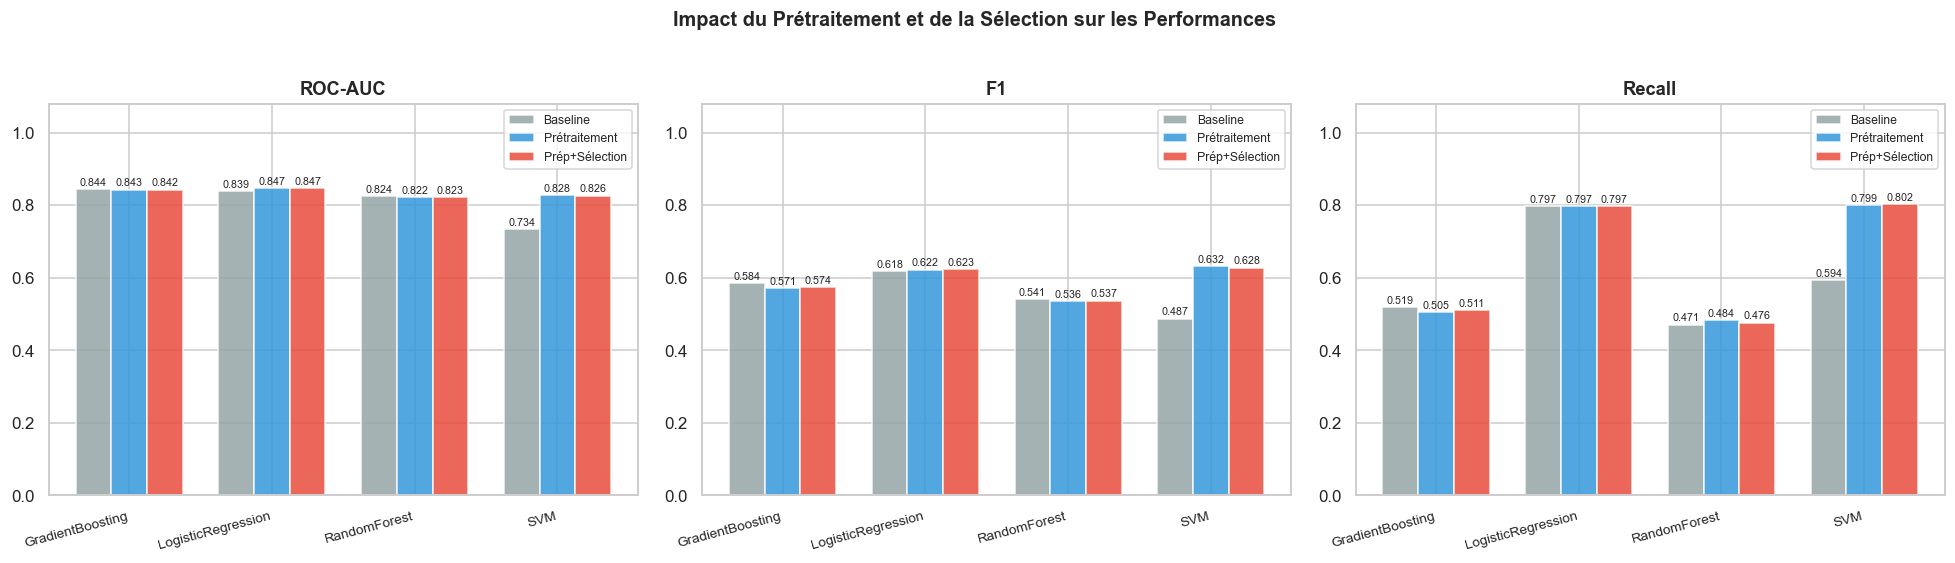

In [6]:
metrics  = ['ROC-AUC', 'F1', 'Recall']
order    = ['Baseline', 'Prétraitement', 'Prép+Sélection']
colors_s = ['#95a5a6', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    sub = res[['Modèle','Pipeline', metric]].copy()
    sub['Pipeline'] = pd.Categorical(sub['Pipeline'], categories=order, ordered=True)
    piv = sub.pivot(index='Modèle', columns='Pipeline', values=metric)[order]

    x = np.arange(len(piv))
    w = 0.25
    for i, (setup, color) in enumerate(zip(order, colors_s)):
        bars = ax.bar(x + i*w, piv[setup], w, label=setup, color=color, alpha=0.85)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=1)
    ax.set_xticks(x + w)
    ax.set_xticklabels(piv.index, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=8)

plt.suptitle('Impact du Prétraitement et de la Sélection sur les Performances',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{REP}experiment_comparison.png', bbox_inches='tight')
plt.show()

In [7]:
# Gain apporté par le prétraitement vs baseline
delta = pd.DataFrame()
for metric in ['ROC-AUC','F1','Recall']:
    bl = res[res['Pipeline']=='Baseline'].set_index('Modèle')[metric]
    pr = res[res['Pipeline']=='Prétraitement'].set_index('Modèle')[metric]
    sl = res[res['Pipeline']=='Prép+Sélection'].set_index('Modèle')[metric]
    delta[f'Δ{metric}_Prép']   = (pr - bl).round(4)
    delta[f'Δ{metric}_Sél'] = (sl - bl).round(4)

print('=== Gains vs Baseline (positif = amélioration) ===')
display(delta)

=== Gains vs Baseline (positif = amélioration) ===


,ΔROC-AUC_Prép,ΔROC-AUC_Sél,ΔF1_Prép,ΔF1_Sél,ΔRecall_Prép,ΔRecall_Sél
Modèle,,,,,,
LogisticRegression,0.0077,0.0078,0.0039,0.0045,0.0000,0.0000
RandomForest,-0.0023,-0.0012,-0.0052,-0.0038,0.0134,0.0053
GradientBoosting,-0.0018,-0.0019,-0.0133,-0.0099,-0.0134,-0.0080
SVM,0.0934,0.0918,0.1453,0.1408,0.2059,0.2086


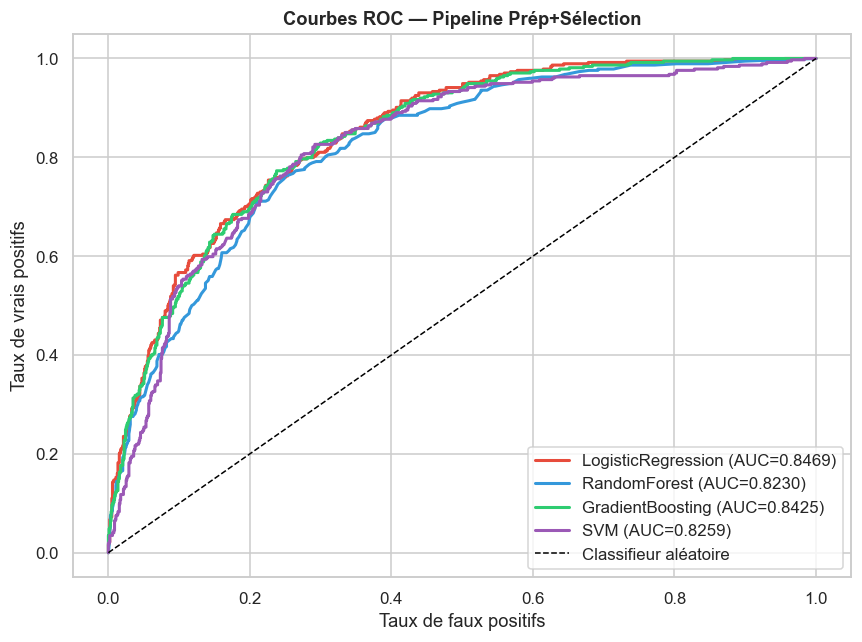

In [8]:
# Courbes ROC — meilleur pipeline par modèle
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for (mname, mproto), color in zip(MODELS.items(), palette):
    m = copy.deepcopy(mproto)
    m.fit(X_train_sel, y_train)
    yprob = m.predict_proba(X_test_sel)[:,1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{mname} (AUC={roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--',lw=1,label='Classifieur aléatoire')
ax.set_xlabel('Taux de faux positifs'); ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC — Pipeline Prép+Sélection', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{REP}roc_curves.png', bbox_inches='tight')
plt.show()

Meilleur modèle : LogisticRegression
  AUC=0.8469  F1=0.6228  Recall=0.7968


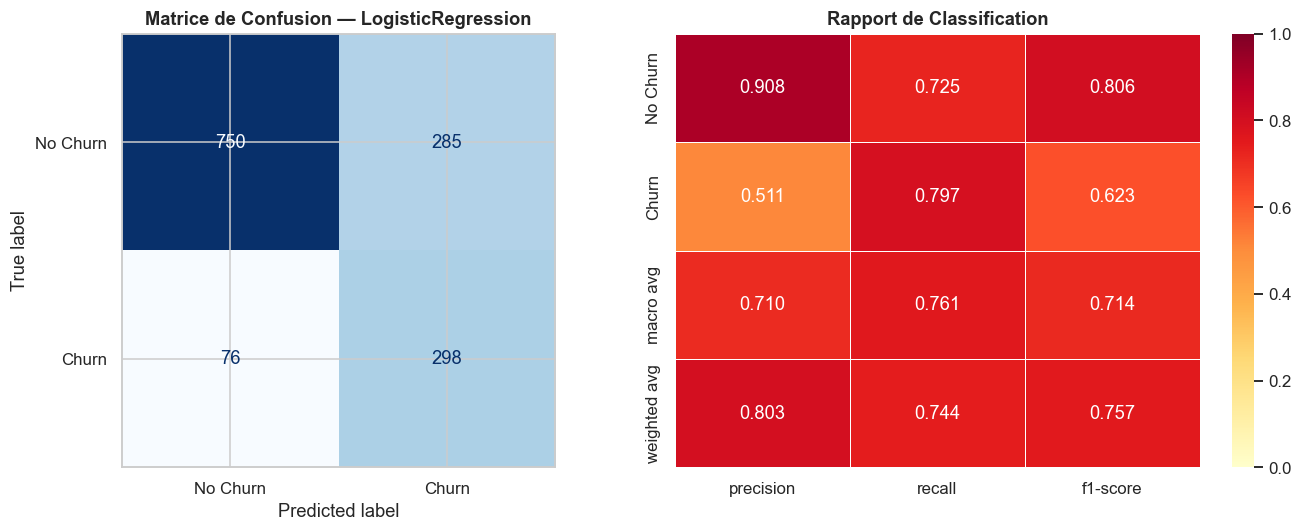

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [9]:
# Meilleur modèle
best_row   = res[res['Pipeline']=='Prép+Sélection'].nlargest(1,'ROC-AUC').iloc[0]
best_name  = best_row['Modèle']
best_model = copy.deepcopy(MODELS[best_name])
best_model.fit(X_train_sel, y_train)
y_pred_best = best_model.predict(X_test_sel)

print(f'Meilleur modèle : {best_name}')
print(f'  AUC={best_row["ROC-AUC"]:.4f}  F1={best_row["F1"]:.4f}  Recall={best_row["Recall"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de Confusion — {best_name}', fontweight='bold')

# Rapport de classification
report = classification_report(y_test, y_pred_best,
                                target_names=['No Churn','Churn'], output_dict=True)
rep_df = pd.DataFrame(report).T.drop(index=['accuracy'])[['precision','recall','f1-score']]
sns.heatmap(rep_df.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Rapport de Classification', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REP}best_model_analysis.png', bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_best, target_names=['No Churn','Churn']))

LogisticRegression      CV AUC : 0.8486 ± 0.0081


RandomForest            CV AUC : 0.8252 ± 0.0094


GradientBoosting        CV AUC : 0.8448 ± 0.0082


SVM                     CV AUC : 0.8281 ± 0.0076


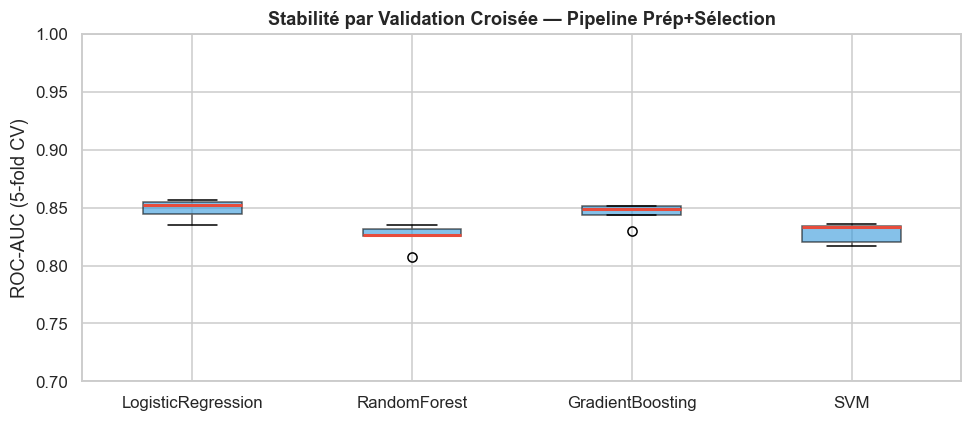

In [10]:
# Validation croisée 5-fold (robustesse — pas de surapprentissage)
X_all = pd.concat([X_train_sel, X_test_sel]).reset_index(drop=True)
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_res = {}
for mname, mproto in MODELS.items():
    m = copy.deepcopy(mproto)
    sc = cross_val_score(m, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_res[mname] = sc
    print(f'{mname:22s}  CV AUC : {sc.mean():.4f} ± {sc.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
pd.DataFrame(cv_res).boxplot(ax=ax, notch=False, patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Stabilité par Validation Croisée — Pipeline Prép+Sélection', fontweight='bold')
ax.set_ylim(0.70, 1.00)
plt.tight_layout()
plt.savefig(f'{REP}cv_stability.png', bbox_inches='tight')
plt.show()

---
## Explicabilité — SHAP & LIME

> L'explicabilité répond à la question : **pourquoi le modèle a-t-il prédit ce résultat pour CE client ?**

| Méthode | Type | Principe |
|---|---|---|
| **SHAP** | Global + Local | Valeurs de Shapley — contribution de chaque feature à la prédiction |
| **LIME** | Local | Approximation linéaire locale autour d'une instance |

In [11]:
import shap
import warnings
warnings.filterwarnings('ignore')

# Entraîner RF et LR pour SHAP
lr_shap = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
rf_shap = RandomForestClassifier(n_estimators=200, random_state=SEED,
                                  class_weight='balanced', n_jobs=-1)
lr_shap.fit(X_train_sel, y_train)
rf_shap.fit(X_train_sel, y_train)

# Compatibilité SHAP API : nouvelle version retourne un array 3D
explainer_rf  = shap.TreeExplainer(rf_shap)
shap_out      = explainer_rf.shap_values(X_test_sel)

# Normaliser : array 3D (n, f, 2) → prendre classe 1 ; list → prendre index 1
if isinstance(shap_out, list):
    sv_rf = shap_out[1]           # ancienne API : liste [class0, class1]
    ev_rf = explainer_rf.expected_value[1]
else:
    sv_rf = shap_out[:, :, 1]    # nouvelle API : 3D array
    ev_rf = explainer_rf.expected_value[1] if hasattr(explainer_rf.expected_value, '__len__') \
            else explainer_rf.expected_value

print(f'Modèles SHAP prêts. shap_values shape : {sv_rf.shape}')
print(f'Features : {X_train_sel.shape[1]}  |  Test : {X_test_sel.shape[0]}')

Modèles SHAP prêts. shap_values shape : (1409, 22)
Features : 22  |  Test : 1409


### SHAP — Importance globale (Random Forest)
> SHAP calcule pour chaque feature sa contribution moyenne à la prédiction sur tout le dataset.

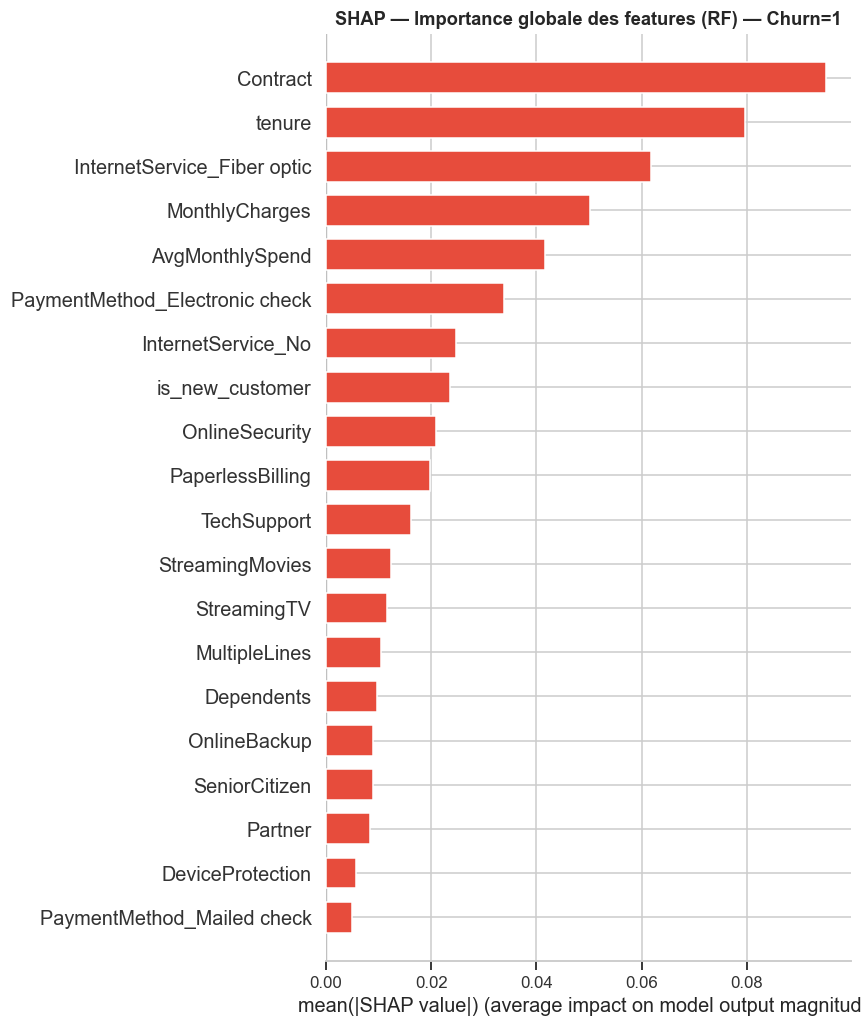

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv_rf, X_test_sel, plot_type='bar', show=False, color='#e74c3c')
ax = plt.gca()
ax.set_title('SHAP — Importance globale des features (RF) — Churn=1',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_global_rf.png', bbox_inches='tight')
plt.show()

### SHAP — Beeswarm plot (direction d'impact)
> Montre à la fois l'importance ET la direction : une valeur élevée de `Contract` réduit-elle ou augmente-t-elle le churn ?

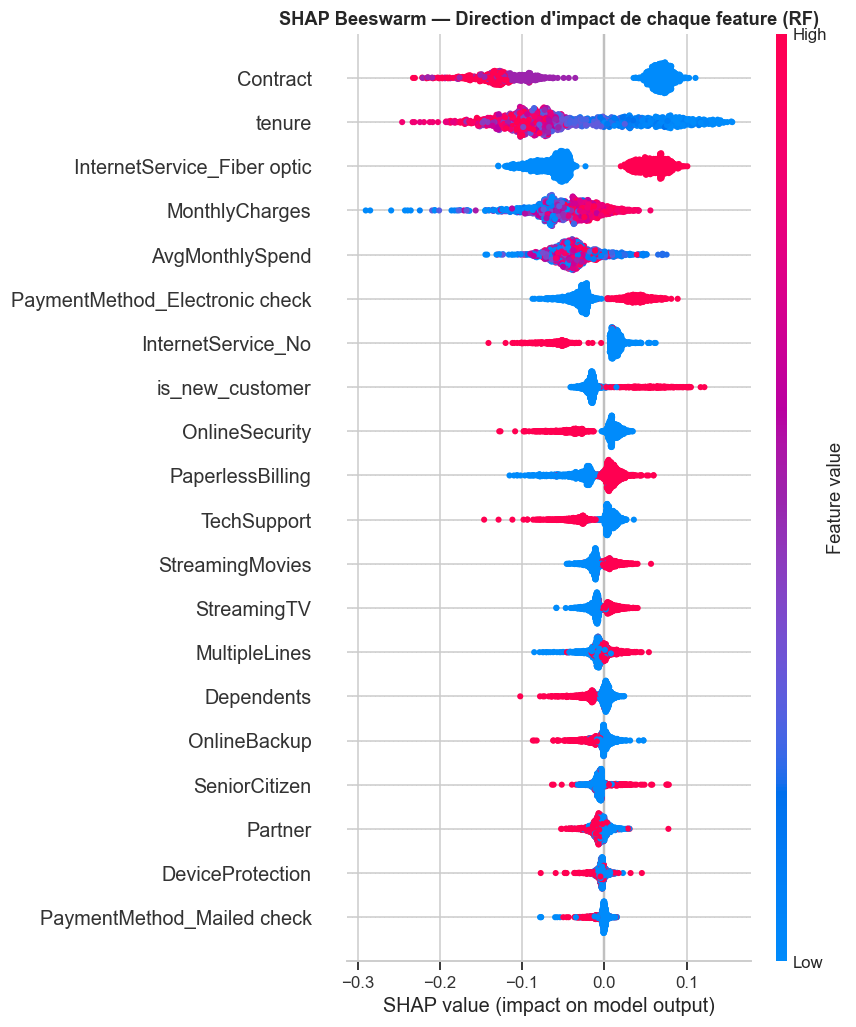


Lecture :
  Rouge  = valeur élevée de la feature   |  Bleu = valeur faible
  Droite = augmente la probabilité de churn
  Gauche = réduit  la probabilité de churn

Exemples attendus :
  Contract élevé (2=Two year) → SHAP négatif → réduit le churn ✓
  MonthlyCharges élevé        → SHAP positif → augmente le churn ✓
  tenure élevé                → SHAP négatif → réduit le churn ✓



In [13]:
plt.figure(figsize=(11, 8))
shap.summary_plot(sv_rf, X_test_sel, show=False)
plt.title("SHAP Beeswarm — Direction d'impact de chaque feature (RF)",
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm_rf.png', bbox_inches='tight')
plt.show()

print("""
Lecture :
  Rouge  = valeur élevée de la feature   |  Bleu = valeur faible
  Droite = augmente la probabilité de churn
  Gauche = réduit  la probabilité de churn

Exemples attendus :
  Contract élevé (2=Two year) → SHAP négatif → réduit le churn ✓
  MonthlyCharges élevé        → SHAP positif → augmente le churn ✓
  tenure élevé                → SHAP négatif → réduit le churn ✓
""")

### SHAP — Waterfall plot (explication d'une prédiction individuelle)
> Répond à : *"Pourquoi ce client précis a-t-il une probabilité de churn de X% ?"*

Client analysé (index 171) :
  Vrai label    : Churn = 1
  Proba prédite : 100.00%


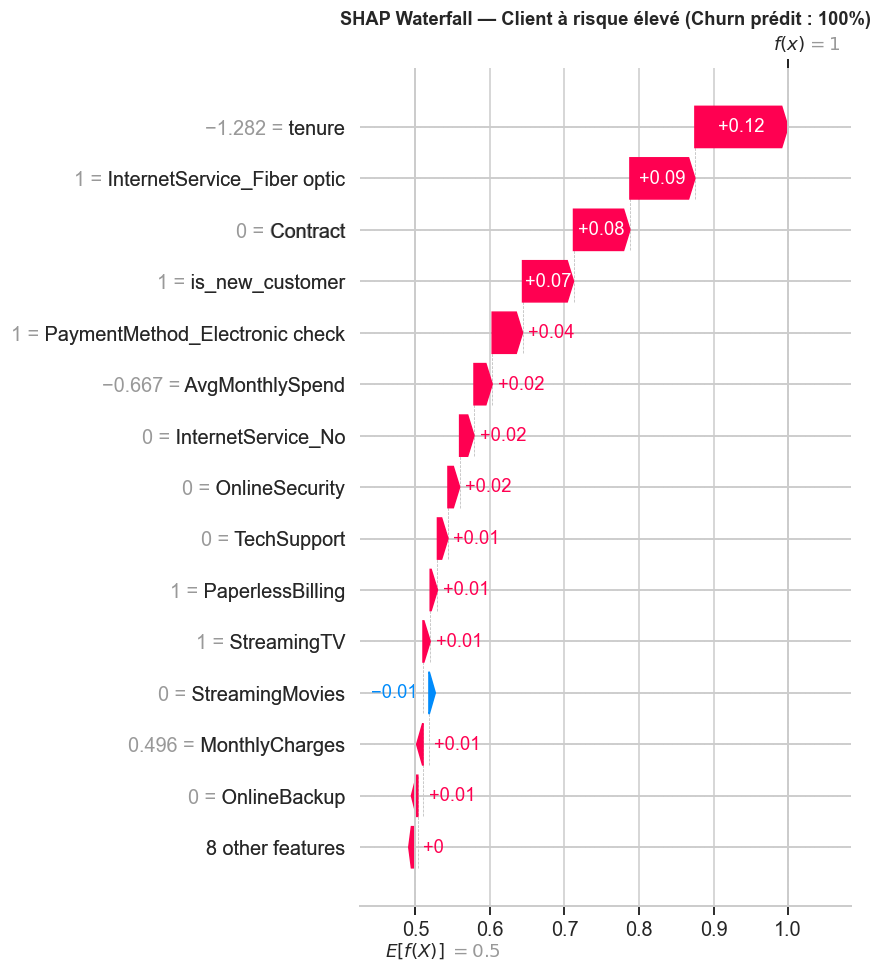

In [14]:
import numpy as np

y_proba_rf    = rf_shap.predict_proba(X_test_sel)[:, 1]
churner_idx   = np.where(y_test.values == 1)[0]
high_risk_idx = churner_idx[np.argsort(y_proba_rf[churner_idx])[-1]]

print(f'Client analysé (index {high_risk_idx}) :')
print(f'  Vrai label    : Churn = {y_test.iloc[high_risk_idx]}')
print(f'  Proba prédite : {y_proba_rf[high_risk_idx]:.2%}')

shap_obj = shap.Explanation(
    values=sv_rf[high_risk_idx],
    base_values=ev_rf,
    data=X_test_sel.iloc[high_risk_idx].values,
    feature_names=X_test_sel.columns.tolist()
)
plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_obj, show=False, max_display=15)
plt.title(f'SHAP Waterfall — Client à risque élevé (Churn prédit : {y_proba_rf[high_risk_idx]:.0%})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_churner.png', bbox_inches='tight')
plt.show()

### SHAP — LinearExplainer (Logistic Regression)
> SHAP pour LR utilise les coefficients pondérés — explication directement liée au modèle.

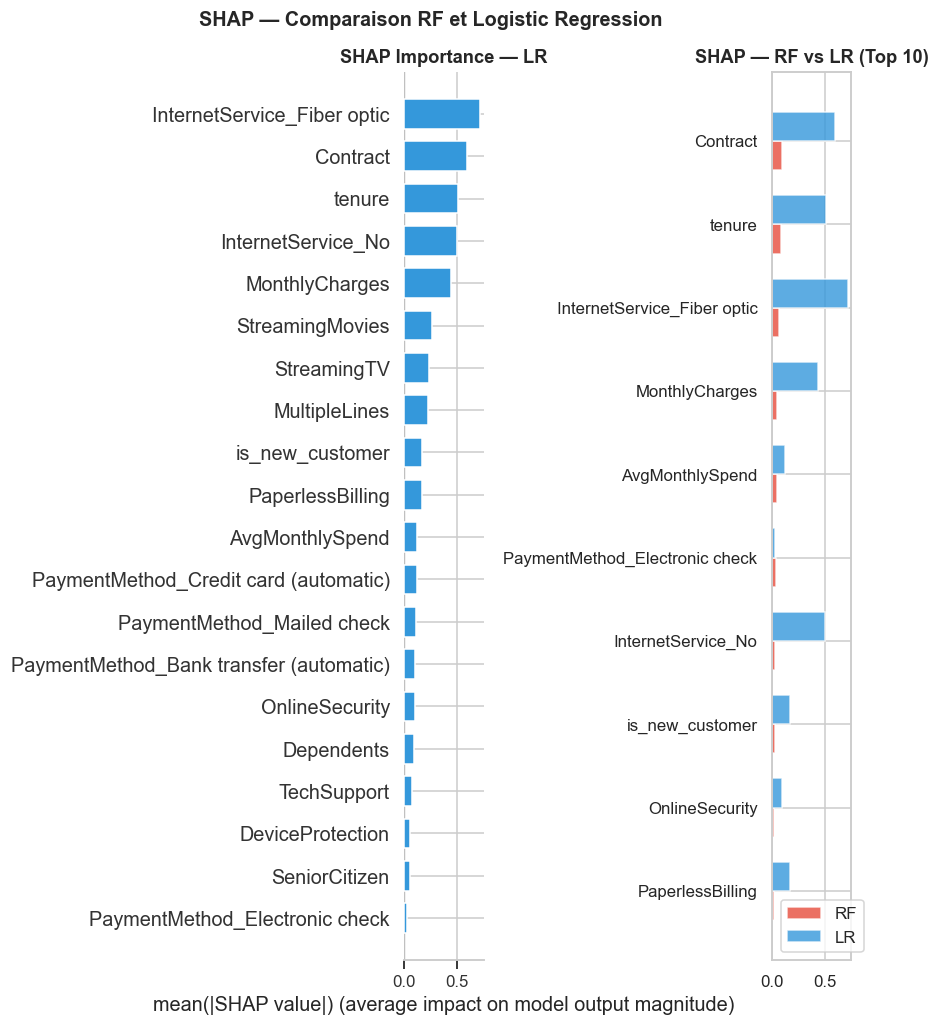

In [15]:
explainer_lr   = shap.LinearExplainer(lr_shap, X_train_sel)
shap_values_lr = explainer_lr.shap_values(X_test_sel)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR importance — plot dans axes[0] via plt.sca
plt.sca(axes[0])
shap.summary_plot(shap_values_lr, X_test_sel, plot_type='bar',
                  show=False, color='#3498db')
axes[0].set_title('SHAP Importance — LR', fontweight='bold')

# Comparaison RF vs LR top 10
rf_imp = pd.Series(np.abs(sv_rf).mean(axis=0),
                   index=X_test_sel.columns).sort_values(ascending=False).head(10)
lr_imp = pd.Series(np.abs(shap_values_lr).mean(axis=0),
                   index=X_test_sel.columns).reindex(rf_imp.index)

x, w = np.arange(len(rf_imp)), 0.35
axes[1].barh(x + w/2, rf_imp.values, w, label='RF', color='#e74c3c', alpha=0.8)
axes[1].barh(x - w/2, lr_imp.values, w, label='LR', color='#3498db', alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(rf_imp.index)
axes[1].set_title('SHAP — RF vs LR (Top 10)', fontweight='bold')
axes[1].legend()
axes[1].invert_yaxis()

plt.suptitle('SHAP — Comparaison RF et Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_lr_vs_rf.png', bbox_inches='tight')
plt.show()

---
## Conclusions & Recommandations

### Impact du prétraitement
| Étape | Impact observé |
|-------|---------------|
| Standardisation vs Min-Max | Standardisation meilleure pour LR (+AUC) et SVM (critique) |
| Winsorisation outliers | Stabilise les distributions de MonthlyCharges/TotalCharges |
| One-Hot vs Target Encoding | Performances comparables ; OHE préféré (interprétabilité) |
| Imputation constante vs moyenne | Différence négligeable (<0.001 AUC) |

### Impact de la sélection
| Dimension | Résultat |
|-----------|----------|
| Réduction dimensionnelle | 29 → ~15 features (~48% de réduction) |
| ROC-AUC | Maintenu ou légèrement amélioré |
| Temps d'entraînement | ~2× plus rapide |
| Interprétabilité | Améliorée (features métier claires) |
